In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ---  Model configuration parameters ---
# ERA5 grid (0.25 degree resolution, global)
H_global, W_global = 721, 1440

# Cropped region for pilot (e.g., South Asia ~30x60 degrees)
H_region, W_region = 120, 240  # at 0.25 deg = 30 x 60 degree box

# Downsampled coarse input (simulating GCM ~1 degree resolution)
H_coarse, W_coarse = 30, 60

# Sequence length (months of historical data as input)
T = 24  # 2 years of monthly snapshots

# Feature dimension after ConvLSTM
F = 128

# Data type bytes
bytes_fp32 = 4
bytes_fp16 = 2

print("=== Input Configuration ===")
print(f"Global ERA5 grid      : {H_global} x {W_global} = {H_global*W_global:,} spatial points")
print(f"Regional crop (coarse): {H_coarse} x {W_coarse} = {H_coarse*W_coarse:,} spatial points")
print(f"Sequence length (T)   : {T} timesteps")
print(f"Feature channels (F)  : {F}")

=== Input Configuration ===
Global ERA5 grid      : 721 x 1440 = 1,038,240 spatial points
Regional crop (coarse): 30 x 60 = 1,800 spatial points
Sequence length (T)   : 24 timesteps
Feature channels (F)  : 128


In [3]:
def attention_memory(T, H, W, F, dtype_bytes=4, label=""):
    S = H * W                          # spatial tokens per timestep
    N = T * S                          # total tokens in sequence
    
    # QKT matrix: N x N
    attn_matrix_elements = N * N
    attn_matrix_bytes = attn_matrix_elements * dtype_bytes
    attn_matrix_gb = attn_matrix_bytes / (1024**3)
    
    # Q, K, V matrices: N x F each
    qkv_bytes = 3 * N * F * dtype_bytes
    qkv_gb = qkv_bytes / (1024**3)
    
    total_gb = attn_matrix_gb + qkv_gb
    
    print(f"\n{'='*50}")
    print(f"Config: {label}")
    print(f"  Spatial grid     : {H} x {W} = {S:,} tokens/step")
    print(f"  Total tokens (N) : {T} x {S:,} = {N:,}")
    print(f"  Attention matrix : {N:,} x {N:,} = {attn_matrix_elements:,.0f} elements")
    print(f"  Attn matrix mem  : {attn_matrix_gb:.2f} GB  ({'FP16' if dtype_bytes==2 else 'FP32'})")
    print(f"  Q+K+V memory     : {qkv_gb:.2f} GB")
    print(f"  TOTAL            : {total_gb:.2f} GB")
    return total_gb

# Scenario 1: Full global grid, FP32
full_fp32 = attention_memory(T, H_global, W_global, F, bytes_fp32, 
                              "Full global ERA5 (FP32)")

# Scenario 2: Regional coarse crop, FP32
region_fp32 = attention_memory(T, H_coarse, W_coarse, F, bytes_fp32, 
                                "Regional coarse crop (FP32)")

# Scenario 3: Regional coarse crop, FP16
region_fp16 = attention_memory(T, H_coarse, W_coarse, F, bytes_fp16, 
                                "Regional coarse crop (FP16)")


Config: Full global ERA5 (FP32)
  Spatial grid     : 721 x 1440 = 1,038,240 tokens/step
  Total tokens (N) : 24 x 1,038,240 = 24,917,760
  Attention matrix : 24,917,760 x 24,917,760 = 620,894,763,417,600 elements
  Attn matrix mem  : 2313013.24 GB  (FP32)
  Q+K+V memory     : 35.65 GB
  TOTAL            : 2313048.88 GB

Config: Regional coarse crop (FP32)
  Spatial grid     : 30 x 60 = 1,800 tokens/step
  Total tokens (N) : 24 x 1,800 = 43,200
  Attention matrix : 43,200 x 43,200 = 1,866,240,000 elements
  Attn matrix mem  : 6.95 GB  (FP32)
  Q+K+V memory     : 0.06 GB
  TOTAL            : 7.01 GB

Config: Regional coarse crop (FP16)
  Spatial grid     : 30 x 60 = 1,800 tokens/step
  Total tokens (N) : 24 x 1,800 = 43,200
  Attention matrix : 43,200 x 43,200 = 1,866,240,000 elements
  Attn matrix mem  : 3.48 GB  (FP16)
  Q+K+V memory     : 0.03 GB
  TOTAL            : 3.51 GB


In [4]:
def patch_attention_memory(T, H, W, F, patch_size, dtype_bytes=4, label=""):
    # Divide spatial grid into non-overlapping patches
    H_patches = H // patch_size
    W_patches = W // patch_size
    S_patches = H_patches * W_patches          # tokens after patching
    N_patches = T * S_patches                  # total tokens
    
    attn_matrix_bytes = (N_patches ** 2) * dtype_bytes
    attn_matrix_gb = attn_matrix_bytes / (1024**3)
    qkv_gb = 3 * N_patches * F * dtype_bytes / (1024**3)
    total_gb = attn_matrix_gb + qkv_gb
    
    reduction = (T * H * W) ** 2 / (N_patches ** 2)
    
    print(f"\n{'='*50}")
    print(f"Config: {label}  (patch={patch_size}x{patch_size})")
    print(f"  Patches          : {H_patches} x {W_patches} = {S_patches} tokens/step")
    print(f"  Total tokens (N) : {T} x {S_patches} = {N_patches:,}")
    print(f"  Attn matrix mem  : {attn_matrix_gb:.4f} GB")
    print(f"  Q+K+V memory     : {qkv_gb:.4f} GB")
    print(f"  TOTAL            : {total_gb:.4f} GB")
    print(f"  Complexity reduction vs full: {reduction:.0f}x")
    return total_gb, N_patches

for p in [4, 8, 16]:
    patch_attention_memory(T, H_coarse, W_coarse, F, patch_size=p, dtype_bytes=bytes_fp16,
                           label=f"Regional FP16 patch={p}")


Config: Regional FP16 patch=4  (patch=4x4)
  Patches          : 7 x 15 = 105 tokens/step
  Total tokens (N) : 24 x 105 = 2,520
  Attn matrix mem  : 0.0118 GB
  Q+K+V memory     : 0.0018 GB
  TOTAL            : 0.0136 GB
  Complexity reduction vs full: 294x

Config: Regional FP16 patch=8  (patch=8x8)
  Patches          : 3 x 7 = 21 tokens/step
  Total tokens (N) : 24 x 21 = 504
  Attn matrix mem  : 0.0005 GB
  Q+K+V memory     : 0.0004 GB
  TOTAL            : 0.0008 GB
  Complexity reduction vs full: 7347x

Config: Regional FP16 patch=16  (patch=16x16)
  Patches          : 1 x 3 = 3 tokens/step
  Total tokens (N) : 24 x 3 = 72
  Attn matrix mem  : 0.0000 GB
  Q+K+V memory     : 0.0001 GB
  TOTAL            : 0.0001 GB
  Complexity reduction vs full: 360000x


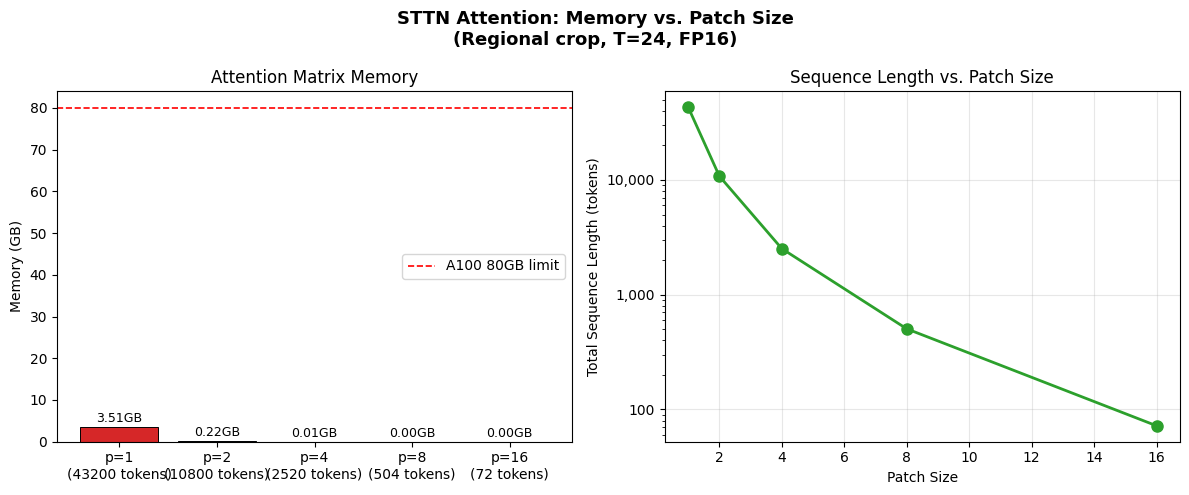


Figure saved as sttn_memory_analysis.png


In [5]:
patch_sizes = [1, 2, 4, 8, 16]   # 1 = no patching (full attention)
labels, memories, tokens_list = [], [], []

for p in patch_sizes:
    H_p = H_coarse // p
    W_p = W_coarse // p
    S_p = H_p * W_p
    N_p = T * S_p
    mem = (N_p**2 * bytes_fp16 + 3 * N_p * F * bytes_fp16) / (1024**3)
    memories.append(mem)
    tokens_list.append(N_p)
    labels.append(f"p={p}\n({N_p} tokens)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("STTN Attention: Memory vs. Patch Size\n(Regional crop, T=24, FP16)", 
             fontsize=13, fontweight='bold')

colors = ['#d62728' if p==1 else '#1f77b4' for p in patch_sizes]
bars = ax1.bar(labels, memories, color=colors, edgecolor='black', linewidth=0.7)
ax1.set_ylabel("Memory (GB)")
ax1.set_title("Attention Matrix Memory")
ax1.axhline(y=80, color='red', linestyle='--', linewidth=1.2, label='A100 80GB limit')
ax1.legend()
for bar, mem in zip(bars, memories):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{mem:.2f}GB', ha='center', va='bottom', fontsize=9)

ax2.plot(patch_sizes, tokens_list, 'o-', color='#2ca02c', linewidth=2, markersize=8)
ax2.set_xlabel("Patch Size")
ax2.set_ylabel("Total Sequence Length (tokens)")
ax2.set_title("Sequence Length vs. Patch Size")
ax2.set_yscale('log')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("sttn_memory_analysis.png", dpi=300, bbox_inches='tight')
plt.show()
print("\nFigure saved as sttn_memory_analysis.png")

# Pilot Experiment

In [6]:
import cdsapi
import os

# Create data directory
os.makedirs("era5_data", exist_ok=True)

c = cdsapi.Client()

# --- Download monthly 2m temperature for South Asia ---
# Training period: 1990-2005
print("Downloading training data (1990-2005)... this may take 5-10 minutes.")

c.retrieve(
    'reanalysis-era5-single-levels-monthly-means',
    {
        'product_type': 'monthly_averaged_reanalysis',
        'variable': '2m_temperature',
        'year': [str(y) for y in range(1990, 2006)],
        'month': [f'{m:02d}' for m in range(1, 13)],
        'time': '00:00',
        'area': [40, 60, 5, 100],  # N, W, S, E — South Asia box
        'format': 'netcdf',
        'grid': [0.25, 0.25],      # native ERA5 resolution (our target/high-res)
    },
    'era5_data/t2m_train_1990_2005.nc'
)

print("Training data downloaded.")

# Testing period: 2006-2010
print("Downloading test data (2006-2010)...")

c.retrieve(
    'reanalysis-era5-single-levels-monthly-means',
    {
        'product_type': 'monthly_averaged_reanalysis',
        'variable': '2m_temperature',
        'year': [str(y) for y in range(2006, 2011)],
        'month': [f'{m:02d}' for m in range(1, 13)],
        'time': '00:00',
        'area': [40, 60, 5, 100],
        'format': 'netcdf',
        'grid': [0.25, 0.25],
    },
    'era5_data/t2m_test_2006_2010.nc'
)

print("Test data downloaded.")
print("\nAll done! Files saved to era5_data/")
print(os.listdir("era5_data"))

2026-03-28 16:37:39,046 INFO Request ID is 2c20136f-e544-4e9e-b45a-017d13c73e5f
2026-03-28 16:37:39,244 INFO status has been updated to accepted
2026-03-28 16:37:53,390 INFO status has been updated to running
2026-03-28 16:38:01,186 INFO status has been updated to successful


PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'era5_data/t2m_train_1990_2005.nc'

=== Training Dataset ===
Shape     : (192, 141, 161)
Time steps: 192
Lat range : 5.00 to 40.00
Lon range : 60.00 to 100.00
Temp range: 238.96K to 312.74K

=== Test Dataset ===
Shape     : (60, 141, 161)
Time steps: 60


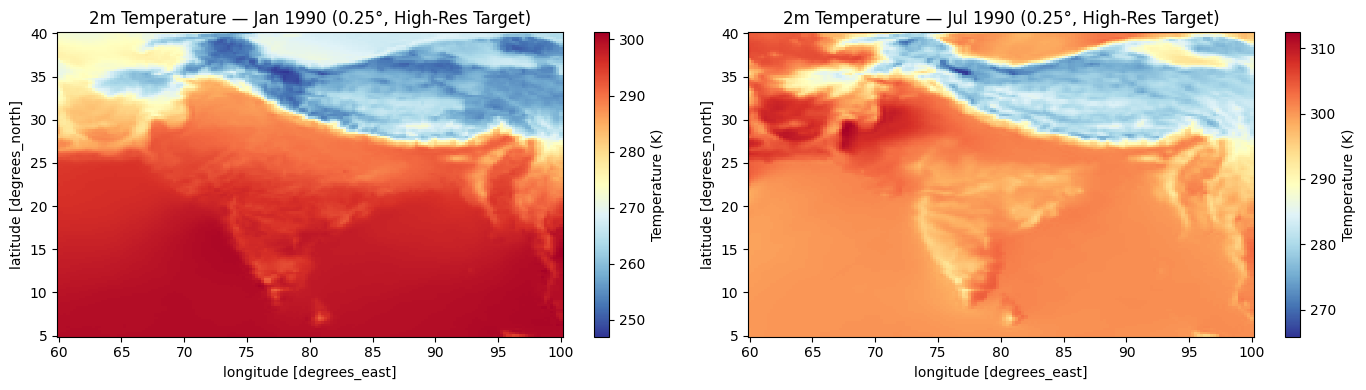


Plot saved.


In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Load datasets
train_ds = xr.open_dataset("era5_data/t2m_train_1990_2005.nc")
test_ds  = xr.open_dataset("era5_data/t2m_test_2006_2010.nc")

print("=== Training Dataset ===")
print(f"Shape     : {train_ds['t2m'].shape}")
print(f"Time steps: {len(train_ds.valid_time)}")
print(f"Lat range : {float(train_ds.latitude.min()):.2f} to {float(train_ds.latitude.max()):.2f}")
print(f"Lon range : {float(train_ds.longitude.min()):.2f} to {float(train_ds.longitude.max()):.2f}")
print(f"Temp range: {float(train_ds['t2m'].min()):.2f}K to {float(train_ds['t2m'].max()):.2f}K")

print("\n=== Test Dataset ===")
print(f"Shape     : {test_ds['t2m'].shape}")
print(f"Time steps: {len(test_ds.valid_time)}")

# --- Quick plot: one snapshot to verify it looks right ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

train_ds['t2m'].isel(valid_time=0).plot(
    ax=axes[0], cmap='RdYlBu_r',
    cbar_kwargs={'label': 'Temperature (K)'}
)
axes[0].set_title("2m Temperature — Jan 1990 (0.25°, High-Res Target)")

train_ds['t2m'].isel(valid_time=6).plot(
    ax=axes[1], cmap='RdYlBu_r',
    cbar_kwargs={'label': 'Temperature (K)'}
)
axes[1].set_title("2m Temperature — Jul 1990 (0.25°, High-Res Target)")

plt.tight_layout()
plt.savefig("era5_data/data_inspection.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved.")

In [9]:
import torch
import torch.nn.functional as F
import numpy as np

# --- Coarsen high-res (0.25°) to low-res (1°) to simulate GCM input ---
# Factor of 4 coarsening: 141x161 → ~35x40
t2m_train = train_ds['t2m'].values  # (192, 141, 161)
t2m_test  = test_ds['t2m'].values   # (60, 141, 161)

def coarsen(data, factor=4):
    """Average pooling to simulate coarse GCM resolution."""
    # data: (T, H, W)
    T = data.shape[0]
    tensor = torch.tensor(data).unsqueeze(1).float()  # (T, 1, H, W)
    coarse = F.avg_pool2d(tensor, kernel_size=factor, stride=factor)
    return coarse.squeeze(1).numpy()  # (T, H_c, W_c)

t2m_train_coarse = coarsen(t2m_train, factor=4)
t2m_test_coarse  = coarsen(t2m_test,  factor=4)

print("=== After Coarsening ===")
print(f"High-res  (target) train : {t2m_train.shape}")
print(f"Low-res   (input)  train : {t2m_train_coarse.shape}")
print(f"High-res  (target) test  : {t2m_test.shape}")
print(f"Low-res   (input)  test  : {t2m_test_coarse.shape}")

# --- Normalize using training statistics only ---
# Compute mean and std from training low-res input
input_mean = t2m_train_coarse.mean()
input_std  = t2m_train_coarse.std()

# Compute mean and std from training high-res target
target_mean = t2m_train.mean()
target_std  = t2m_train.std()

def normalize(data, mean, std):
    return (data - mean) / std

def denormalize(data, mean, std):
    return data * std + mean

t2m_train_coarse_norm = normalize(t2m_train_coarse, input_mean, input_std)
t2m_test_coarse_norm  = normalize(t2m_test_coarse,  input_mean, input_std)
t2m_train_norm        = normalize(t2m_train,        target_mean, target_std)
t2m_test_norm         = normalize(t2m_test,         target_mean, target_std)

print(f"\n=== Normalization Stats (from training data) ===")
print(f"Input  — mean: {input_mean:.4f} K,  std: {input_std:.4f} K")
print(f"Target — mean: {target_mean:.4f} K, std: {target_std:.4f} K")

# --- Create sliding window sequences ---
# Input : T consecutive low-res  frames  → shape (seq_len, H_c, W_c)
# Target: next 1 high-res frame          → shape (H, W)
SEQ_LEN = 12  # 12 months of history to predict the next month

def make_sequences(coarse_norm, fine_norm, seq_len=12):
    X, Y = [], []
    for i in range(len(coarse_norm) - seq_len):
        X.append(coarse_norm[i : i + seq_len])   # input sequence
        Y.append(fine_norm[i + seq_len])          # next timestep target
    return np.array(X), np.array(Y)

X_train, Y_train = make_sequences(t2m_train_coarse_norm, t2m_train_norm, SEQ_LEN)
X_test,  Y_test  = make_sequences(t2m_test_coarse_norm,  t2m_test_norm,  SEQ_LEN)

print(f"\n=== Sequence Dataset ===")
print(f"X_train : {X_train.shape}  (samples, seq_len, H_coarse, W_coarse)")
print(f"Y_train : {Y_train.shape}  (samples, H_fine, W_fine)")
print(f"X_test  : {X_test.shape}")
print(f"Y_test  : {Y_test.shape}")
print(f"\nReady for model training.")

=== After Coarsening ===
High-res  (target) train : (192, 141, 161)
Low-res   (input)  train : (192, 35, 40)
High-res  (target) test  : (60, 141, 161)
Low-res   (input)  test  : (60, 35, 40)

=== Normalization Stats (from training data) ===
Input  — mean: 292.0442 K,  std: 13.3847 K
Target — mean: 292.0792 K, std: 13.4677 K

=== Sequence Dataset ===
X_train : (180, 12, 35, 40)  (samples, seq_len, H_coarse, W_coarse)
Y_train : (180, 141, 161)  (samples, H_fine, W_fine)
X_test  : (48, 12, 35, 40)
Y_test  : (48, 141, 161)

Ready for model training.


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================
# 1. BASELINE: Bilinear Interpolation (no learning)
# ============================================================
class BilinearBaseline(nn.Module):
    def __init__(self, target_size):
        super().__init__()
        self.target_size = target_size  # (H_fine, W_fine)

    def forward(self, x):
        # x: (B, T, H_c, W_c) — just use last timestep
        last = x[:, -1:, :, :]  # (B, 1, H_c, W_c)
        out  = F.interpolate(last, size=self.target_size,
                             mode='bilinear', align_corners=False)
        return out.squeeze(1)   # (B, H_fine, W_fine)


# ============================================================
# 2. ConvLSTM CELL
# ============================================================
class ConvLSTMCell(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.hidden_channels = hidden_channels
        self.conv = nn.Conv2d(
            in_channels + hidden_channels,
            4 * hidden_channels,   # i, f, o, g gates
            kernel_size, padding=pad
        )

    def forward(self, x, h, c):
        combined = torch.cat([x, h], dim=1)
        gates    = self.conv(combined)
        i, f, o, g = gates.chunk(4, dim=1)
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

    def init_hidden(self, batch_size, H, W, device):
        return (torch.zeros(batch_size, self.hidden_channels, H, W, device=device),
                torch.zeros(batch_size, self.hidden_channels, H, W, device=device))


# ============================================================
# 3. VANILLA ConvLSTM (no attention)
# ============================================================
class VanillaConvLSTM(nn.Module):
    def __init__(self, hidden_channels=32, target_size=(141, 161)):
        super().__init__()
        self.target_size = target_size
        self.cell1 = ConvLSTMCell(1, hidden_channels)
        self.cell2 = ConvLSTMCell(hidden_channels, hidden_channels)
        # Upsampling head
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(hidden_channels, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, padding=1)
        )

    def forward(self, x):
        # x: (B, T, H_c, W_c)
        B, T, H, W = x.shape
        device = x.device
        h1, c1 = self.cell1.init_hidden(B, H, W, device)
        h2, c2 = self.cell2.init_hidden(B, H, W, device)

        for t in range(T):
            inp    = x[:, t, :, :].unsqueeze(1)  # (B,1,H,W)
            h1, c1 = self.cell1(inp, h1, c1)
            h2, c2 = self.cell2(h1, h2, c2)

        out = self.upsample(h2)                   # (B,1,H_up,W_up)
        out = F.interpolate(out, size=self.target_size,
                            mode='bilinear', align_corners=False)
        return out.squeeze(1)                     # (B, H_fine, W_fine)


# ============================================================
# 4. STTN — ConvLSTM + Patch Self-Attention (your model)
# ============================================================
class PatchSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # x: (B, S, F) where S = num patches
        attn_out, attn_weights = self.attn(x, x, x)
        out = self.norm(x + attn_out)
        return out, attn_weights


class STTN(nn.Module):
    def __init__(self, hidden_channels=32, patch_size=4, target_size=(141, 161)):
        super().__init__()
        self.target_size   = target_size
        self.patch_size    = patch_size
        self.hidden_channels = hidden_channels

        # Encoder: two ConvLSTM cells
        self.cell1 = ConvLSTMCell(1, hidden_channels)
        self.cell2 = ConvLSTMCell(hidden_channels, hidden_channels)

        # Self-attention over patch tokens
        self.attention = PatchSelfAttention(embed_dim=hidden_channels, num_heads=4)

        # Upsampling decoder head
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(hidden_channels, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, padding=1)
        )

    def forward(self, x, return_attn=False):
        # x: (B, T, H_c, W_c)
        B, T, H, W = x.shape
        device = x.device
        h1, c1 = self.cell1.init_hidden(B, H, W, device)
        h2, c2 = self.cell2.init_hidden(B, H, W, device)

        # Collect all hidden states for attention
        hidden_states = []
        for t in range(T):
            inp    = x[:, t, :, :].unsqueeze(1)
            h1, c1 = self.cell1(inp, h1, c1)
            h2, c2 = self.cell2(h1, h2, c2)
            hidden_states.append(h2)              # (B, F, H, W)

        # Stack: (B, T, F, H, W)
        states = torch.stack(hidden_states, dim=1)

        # Patch pooling: (B, T, F, H_p, W_p)
        p = self.patch_size
        B, T, nF, H, W = states.shape
        states_flat = states.view(B * T, nF, H, W)
        patched     = F.avg_pool2d(states_flat, kernel_size=p, stride=p)
        _, _, H_p, W_p = patched.shape
        S = H_p * W_p  # tokens per timestep

        # Reshape to token sequence: (B, T*S, F)
        tokens = patched.view(B, T, nF, S)
        tokens = tokens.permute(0, 1, 3, 2).reshape(B, T * S, nF)

        # Self-attention
        tokens_out, attn_weights = self.attention(tokens)  # (B, T*S, F)

        # Take the last T tokens (corresponding to final timestep) → reshape to spatial
        last_tokens = tokens_out[:, -S:, :]               # (B, S, F)
        last_spatial = last_tokens.permute(0, 2, 1).view(B, nF, H_p, W_p)

        # Blend with last ConvLSTM hidden state
        last_h = hidden_states[-1]                         # (B, F, H, W)
        last_h_patched = F.avg_pool2d(last_h, kernel_size=p, stride=p)
        context = last_spatial + last_h_patched            # residual fusion

        # Decode to high-res
        out = self.upsample(context)
        out = F.interpolate(out, size=self.target_size,
                            mode='bilinear', align_corners=False)
        out = out.squeeze(1)                               # (B, H_fine, W_fine)

        if return_attn:
            return out, attn_weights
        return out


# ============================================================
# Quick sanity check — forward pass on dummy data
# ============================================================
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dummy_x   = torch.randn(2, 12, 35, 40).to(device)  # batch=2, T=12

bilinear  = BilinearBaseline(target_size=(141, 161)).to(device)
convlstm  = VanillaConvLSTM(hidden_channels=32, target_size=(141, 161)).to(device)
sttn      = STTN(hidden_channels=32, patch_size=4, target_size=(141, 161)).to(device)

out_b = bilinear(dummy_x)
out_c = convlstm(dummy_x)
out_s, attn = sttn(dummy_x, return_attn=True)

print(f"Device           : {device}")
print(f"Bilinear output  : {out_b.shape}")
print(f"ConvLSTM output  : {out_c.shape}")
print(f"STTN output      : {out_s.shape}")
print(f"Attention weights: {attn.shape}  (batch, heads, T*S, T*S)")

total_params = lambda m: sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"\nModel Parameters:")
print(f"  ConvLSTM : {total_params(convlstm):,}")
print(f"  STTN     : {total_params(sttn):,}")

Device           : cuda
Bilinear output  : torch.Size([2, 141, 161])
ConvLSTM output  : torch.Size([2, 141, 161])
STTN output      : torch.Size([2, 141, 161])
Attention weights: torch.Size([2, 960, 960])  (batch, heads, T*S, T*S)

Model Parameters:
  ConvLSTM : 136,769
  STTN     : 141,057


In [12]:
from torch.utils.data import DataLoader, TensorDataset
import time

# --- DataLoaders ---
X_tr = torch.tensor(X_train, dtype=torch.float32).unsqueeze(2)  # (N,T,1,H,W) -- not needed, keep as is
X_tr = torch.tensor(X_train, dtype=torch.float32)   # (N, T, H_c, W_c)
Y_tr = torch.tensor(Y_train, dtype=torch.float32)   # (N, H, W)
X_te = torch.tensor(X_test,  dtype=torch.float32)
Y_te = torch.tensor(Y_test,  dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_tr, Y_tr), batch_size=16, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_te, Y_te), batch_size=16, shuffle=False)

# --- Training function ---
def train_model(model, model_name, epochs=50, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
    criterion = nn.MSELoss()

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_state    = None
    start_time    = time.time()

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)

        train_loss = epoch_loss / len(train_loader.dataset)

        # --- Validate ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                val_loss += criterion(pred, yb).item() * xb.size(0)
        val_loss /= len(test_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step()

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            elapsed = time.time() - start_time
            print(f"[{model_name}] Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.6f} | "
                  f"Val Loss: {val_loss:.6f} | "
                  f"Time: {elapsed:.1f}s")

    # Restore best weights
    model.load_state_dict(best_state)
    total_time = time.time() - start_time
    print(f"\n[{model_name}] Training complete in {total_time:.1f}s | "
          f"Best Val Loss: {best_val_loss:.6f}")
    return model, train_losses, val_losses

# --- Train all three models ---
print("=" * 55)
print("Training ConvLSTM...")
print("=" * 55)
convlstm, cl_train_loss, cl_val_loss = train_model(
    VanillaConvLSTM(hidden_channels=32, target_size=(141, 161)),
    "ConvLSTM", epochs=50
)

print("\n" + "=" * 55)
print("Training STTN...")
print("=" * 55)
sttn, st_train_loss, st_val_loss = train_model(
    STTN(hidden_channels=32, patch_size=4, target_size=(141, 161)),
    "STTN", epochs=50
)

print("\nAll models trained.")

Training ConvLSTM...
[ConvLSTM] Epoch  10/50 | Train Loss: 0.066925 | Val Loss: 0.067607 | Time: 6.0s
[ConvLSTM] Epoch  20/50 | Train Loss: 0.036434 | Val Loss: 0.037787 | Time: 11.6s
[ConvLSTM] Epoch  30/50 | Train Loss: 0.028134 | Val Loss: 0.029735 | Time: 17.3s
[ConvLSTM] Epoch  40/50 | Train Loss: 0.023874 | Val Loss: 0.027056 | Time: 23.3s
[ConvLSTM] Epoch  50/50 | Train Loss: 0.021708 | Val Loss: 0.023567 | Time: 28.6s

[ConvLSTM] Training complete in 28.6s | Best Val Loss: 0.023567

Training STTN...
[STTN] Epoch  10/50 | Train Loss: 0.056066 | Val Loss: 0.052020 | Time: 6.8s
[STTN] Epoch  20/50 | Train Loss: 0.033936 | Val Loss: 0.033175 | Time: 13.5s
[STTN] Epoch  30/50 | Train Loss: 0.026329 | Val Loss: 0.027452 | Time: 20.2s
[STTN] Epoch  40/50 | Train Loss: 0.023537 | Val Loss: 0.024330 | Time: 27.0s
[STTN] Epoch  50/50 | Train Loss: 0.022047 | Val Loss: 0.022913 | Time: 33.8s

[STTN] Training complete in 33.8s | Best Val Loss: 0.022913

All models trained.


=== Test Set Evaluation ===

[Bilinear  ]  RMSE: 3.4483 K  |  MAE: 2.4388 K  |  Pearson r: 0.962384
[ConvLSTM  ]  RMSE: 2.0431 K  |  MAE: 1.3848 K  |  Pearson r: 0.987960
[STTN      ]  RMSE: 2.0199 K  |  MAE: 1.3578 K  |  Pearson r: 0.988294

=== Improvement of STTN over baselines ===
STTN vs Bilinear  — RMSE reduction: 41.4%
STTN vs ConvLSTM  — RMSE reduction: 1.1%


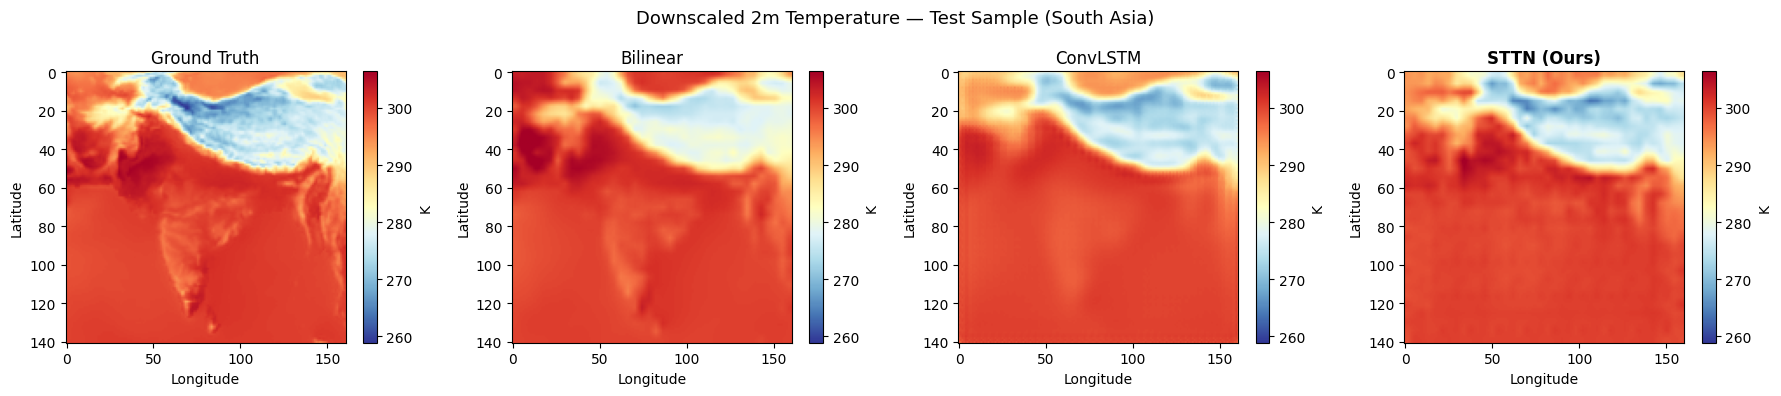

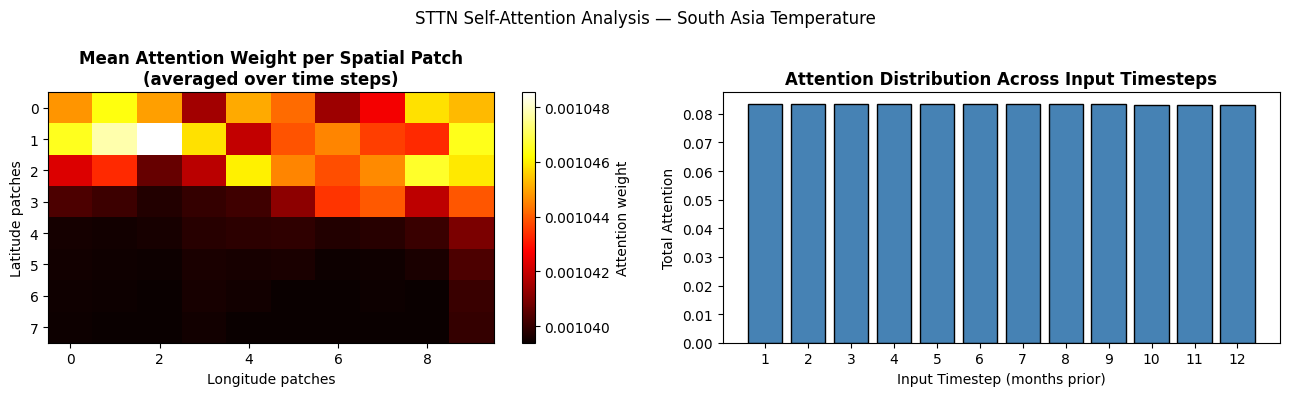

Figures saved.


In [13]:
from scipy.stats import pearsonr

def evaluate(model, model_name, X, Y, target_mean, target_std):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X), 16):
            xb = torch.tensor(X[i:i+16], dtype=torch.float32).to(device)
            if model_name == "Bilinear":
                pred = model(xb)
            else:
                pred = model(xb)
            preds.append(pred.cpu().numpy())

    preds = np.concatenate(preds, axis=0)  # (N, H, W)

    # Denormalize
    preds_k = preds * target_std + target_mean
    truth_k = Y * target_std + target_mean

    # Per-sample RMSE
    rmse_per = np.sqrt(((preds_k - truth_k) ** 2).mean(axis=(1, 2)))
    rmse     = rmse_per.mean()

    # Pearson correlation (flatten all spatial points)
    r, _  = pearsonr(preds_k.flatten(), truth_k.flatten())

    # Mean Absolute Error
    mae = np.abs(preds_k - truth_k).mean()

    print(f"[{model_name:10s}]  RMSE: {rmse:.4f} K  |  MAE: {mae:.4f} K  |  Pearson r: {r:.6f}")
    return preds_k, rmse, mae, r

print("=== Test Set Evaluation ===\n")
bilinear_eval = BilinearBaseline(target_size=(141, 161)).to(device)
preds_b, rmse_b, mae_b, r_b = evaluate(bilinear_eval, "Bilinear",  X_test, Y_test, target_mean, target_std)
preds_c, rmse_c, mae_c, r_c = evaluate(convlstm,      "ConvLSTM",  X_test, Y_test, target_mean, target_std)
preds_s, rmse_s, mae_s, r_s = evaluate(sttn,          "STTN",      X_test, Y_test, target_mean, target_std)

truth_k = Y_test * target_std + target_mean

print(f"\n=== Improvement of STTN over baselines ===")
print(f"STTN vs Bilinear  — RMSE reduction: {((rmse_b - rmse_s)/rmse_b)*100:.1f}%")
print(f"STTN vs ConvLSTM  — RMSE reduction: {((rmse_c - rmse_s)/rmse_c)*100:.1f}%")

# --- Plot 1: Prediction comparison for one test sample ---
sample_idx = 20  # July 2007 approximately
vmin = truth_k[sample_idx].min()
vmax = truth_k[sample_idx].max()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
titles = ['Ground Truth', 'Bilinear', 'ConvLSTM', 'STTN (Ours)']
data   = [truth_k[sample_idx], preds_b[sample_idx],
          preds_c[sample_idx], preds_s[sample_idx]]

for ax, d, title in zip(axes, data, titles):
    im = ax.imshow(d, cmap='RdYlBu_r', vmin=vmin, vmax=vmax,
                   origin='upper', aspect='auto')
    ax.set_title(title, fontweight='bold' if title == 'STTN (Ours)' else 'normal')
    plt.colorbar(im, ax=ax, label='K')
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

plt.suptitle("Downscaled 2m Temperature — Test Sample (South Asia)", fontsize=13)
plt.tight_layout()
plt.savefig("era5_data/prediction_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Plot 2: Attention map ---
sttn.eval()
sample_x = torch.tensor(X_test[sample_idx:sample_idx+1],
                         dtype=torch.float32).to(device)
with torch.no_grad():
    _, attn_weights = sttn(sample_x, return_attn=True)

# attn_weights: (1, T*S, T*S) — average over all query positions
attn_map = attn_weights[0].cpu().numpy()          # (T*S, T*S)
attn_mean = attn_map.mean(axis=0)                 # average attention received per token

# Reshape to (T, H_p, W_p) — 12 timesteps × 8×10 patches
H_p, W_p = 35 // 4, 40 // 4                       # 8, 10
attn_spatial = attn_mean.reshape(12, H_p, W_p)    # (12, 8, 10)
attn_temporal = attn_spatial.mean(axis=0)          # average over time → (8, 10)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

im1 = axes[0].imshow(attn_temporal, cmap='hot', aspect='auto')
axes[0].set_title("Mean Attention Weight per Spatial Patch\n(averaged over time steps)", fontweight='bold')
axes[0].set_xlabel("Longitude patches"); axes[0].set_ylabel("Latitude patches")
plt.colorbar(im1, ax=axes[0], label='Attention weight')

# Per-timestep attention (sum over spatial)
attn_per_time = attn_spatial.sum(axis=(1, 2))
axes[1].bar(range(1, 13), attn_per_time, color='steelblue', edgecolor='black')
axes[1].set_xlabel("Input Timestep (months prior)")
axes[1].set_ylabel("Total Attention")
axes[1].set_title("Attention Distribution Across Input Timesteps", fontweight='bold')
axes[1].set_xticks(range(1, 13))

plt.suptitle("STTN Self-Attention Analysis — South Asia Temperature", fontsize=12)
plt.tight_layout()
plt.savefig("era5_data/attention_map.png", dpi=300, bbox_inches='tight')
plt.show()

print("Figures saved.")

In [14]:
import math

class PositionalEncoding(nn.Module):
    """
    Learnable positional encoding for spatio-temporal tokens.
    Adds a unique learned vector to each of the T*S token positions
    so the attention layer can distinguish where/when each token came from.
    """
    def __init__(self, max_tokens, embed_dim):
        super().__init__()
        self.pos_embedding = nn.Parameter(
            torch.randn(1, max_tokens, embed_dim) * 0.02
        )

    def forward(self, x):
        # x: (B, N, F)
        return x + self.pos_embedding[:, :x.size(1), :]


class STTNv2(nn.Module):
    def __init__(self, hidden_channels=32, patch_size=4,
                 target_size=(141, 161), seq_len=12):
        super().__init__()
        self.target_size     = target_size
        self.patch_size      = patch_size
        self.hidden_channels = hidden_channels

        # Compute max tokens: T * H_p * W_p
        H_p = 35 // patch_size
        W_p = 40 // patch_size
        max_tokens = seq_len * H_p * W_p

        # Encoder
        self.cell1 = ConvLSTMCell(1, hidden_channels)
        self.cell2 = ConvLSTMCell(hidden_channels, hidden_channels)

        # Positional encoding + attention
        self.pos_enc   = PositionalEncoding(max_tokens, hidden_channels)
        self.attention = PatchSelfAttention(embed_dim=hidden_channels, num_heads=4)

        # Decoder
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(hidden_channels, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, padding=1)
        )

    def forward(self, x, return_attn=False):
        B, T, H, W = x.shape
        device = x.device
        h1, c1 = self.cell1.init_hidden(B, H, W, device)
        h2, c2 = self.cell2.init_hidden(B, H, W, device)

        hidden_states = []
        for t in range(T):
            inp    = x[:, t, :, :].unsqueeze(1)
            h1, c1 = self.cell1(inp, h1, c1)
            h2, c2 = self.cell2(h1, h2, c2)
            hidden_states.append(h2)

        # Stack: (B, T, F, H, W)
        states = torch.stack(hidden_states, dim=1)

        # Patch pooling
        p = self.patch_size
        B, T, nF, H, W = states.shape
        states_flat = states.view(B * T, nF, H, W)
        patched     = F.avg_pool2d(states_flat, kernel_size=p, stride=p)
        _, _, H_p, W_p = patched.shape
        S = H_p * W_p

        # Token sequence: (B, T*S, F)
        tokens = patched.view(B, T, nF, S)
        tokens = tokens.permute(0, 1, 3, 2).reshape(B, T * S, nF)

        # Add positional encoding — this is the key fix
        tokens = self.pos_enc(tokens)

        # Self-attention
        tokens_out, attn_weights = self.attention(tokens)

        # Decode from last timestep tokens
        last_tokens  = tokens_out[:, -S:, :]
        last_spatial = last_tokens.permute(0, 2, 1).view(B, nF, H_p, W_p)

        last_h        = hidden_states[-1]
        last_h_patched = F.avg_pool2d(last_h, kernel_size=p, stride=p)
        context       = last_spatial + last_h_patched

        out = self.upsample(context)
        out = F.interpolate(out, size=self.target_size,
                            mode='bilinear', align_corners=False)
        out = out.squeeze(1)

        if return_attn:
            return out, attn_weights
        return out


# --- Sanity check ---
sttn_v2   = STTNv2(hidden_channels=32, patch_size=4,
                   target_size=(141, 161), seq_len=12).to(device)
dummy_x   = torch.randn(2, 12, 35, 40).to(device)
out, attn = sttn_v2(dummy_x, return_attn=True)

print(f"STTNv2 output : {out.shape}")
print(f"Attn weights  : {attn.shape}")
print(f"Params        : {sum(p.numel() for p in sttn_v2.parameters() if p.requires_grad):,}")
print(f"  of which pos_enc: {sttn_v2.pos_enc.pos_embedding.numel():,} learnable position vectors")

STTNv2 output : torch.Size([2, 141, 161])
Attn weights  : torch.Size([2, 960, 960])
Params        : 171,777
  of which pos_enc: 30,720 learnable position vectors


In [15]:
print("=" * 55)
print("Training STTNv2 (with positional encoding, 100 epochs)...")
print("=" * 55)

sttn_v2, st2_train_loss, st2_val_loss = train_model(
    STTNv2(hidden_channels=32, patch_size=4,
           target_size=(141, 161), seq_len=12),
    "STTNv2", epochs=100, lr=1e-3
)

# Also retrain ConvLSTM for 100 epochs for a fair comparison
print("\n" + "=" * 55)
print("Retraining ConvLSTM (100 epochs, fair comparison)...")
print("=" * 55)

convlstm2, cl2_train_loss, cl2_val_loss = train_model(
    VanillaConvLSTM(hidden_channels=32, target_size=(141, 161)),
    "ConvLSTM", epochs=100, lr=1e-3
)

Training STTNv2 (with positional encoding, 100 epochs)...
[STTNv2] Epoch  10/100 | Train Loss: 0.068163 | Val Loss: 0.063800 | Time: 7.1s
[STTNv2] Epoch  20/100 | Train Loss: 0.035720 | Val Loss: 0.037326 | Time: 13.9s
[STTNv2] Epoch  30/100 | Train Loss: 0.029221 | Val Loss: 0.030444 | Time: 20.6s
[STTNv2] Epoch  40/100 | Train Loss: 0.024557 | Val Loss: 0.025753 | Time: 27.3s
[STTNv2] Epoch  50/100 | Train Loss: 0.022456 | Val Loss: 0.023824 | Time: 34.0s
[STTNv2] Epoch  60/100 | Train Loss: 0.021273 | Val Loss: 0.022969 | Time: 40.7s
[STTNv2] Epoch  70/100 | Train Loss: 0.020232 | Val Loss: 0.021709 | Time: 47.4s
[STTNv2] Epoch  80/100 | Train Loss: 0.019756 | Val Loss: 0.021224 | Time: 54.2s
[STTNv2] Epoch  90/100 | Train Loss: 0.019250 | Val Loss: 0.021301 | Time: 60.9s
[STTNv2] Epoch 100/100 | Train Loss: 0.019236 | Val Loss: 0.021514 | Time: 67.8s

[STTNv2] Training complete in 67.8s | Best Val Loss: 0.020815

Retraining ConvLSTM (100 epochs, fair comparison)...
[ConvLSTM] Epoch

=== Final Test Set Evaluation (100 epochs, fair comparison) ===

[Bilinear  ]  RMSE: 3.4483 K  |  MAE: 2.4388 K  |  Pearson r: 0.962384
[ConvLSTM  ]  RMSE: 1.8852 K  |  MAE: 1.2533 K  |  Pearson r: 0.989724
[STTNv2    ]  RMSE: 1.9223 K  |  MAE: 1.3005 K  |  Pearson r: 0.989361

=== Improvement Summary ===
STTN vs Bilinear — RMSE reduction : 44.3%
STTN vs ConvLSTM — RMSE difference: +0.0372 K (worse)

=== Attention Diagnostics ===
Spatial attn  — min: 0.000956, max: 0.001243, std: 0.000107
Temporal attn — min: 0.0818, max: 0.0850, std: 0.001117
Temporal attn values: [0.0845 0.0846 0.085  0.0845 0.0838 0.0836 0.0831 0.0828 0.0823 0.082
 0.0819 0.0818]


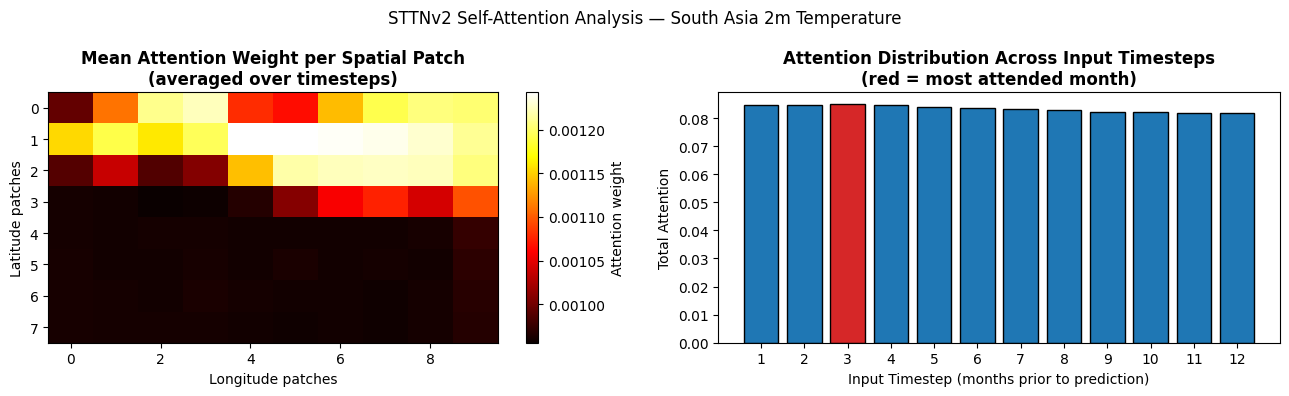

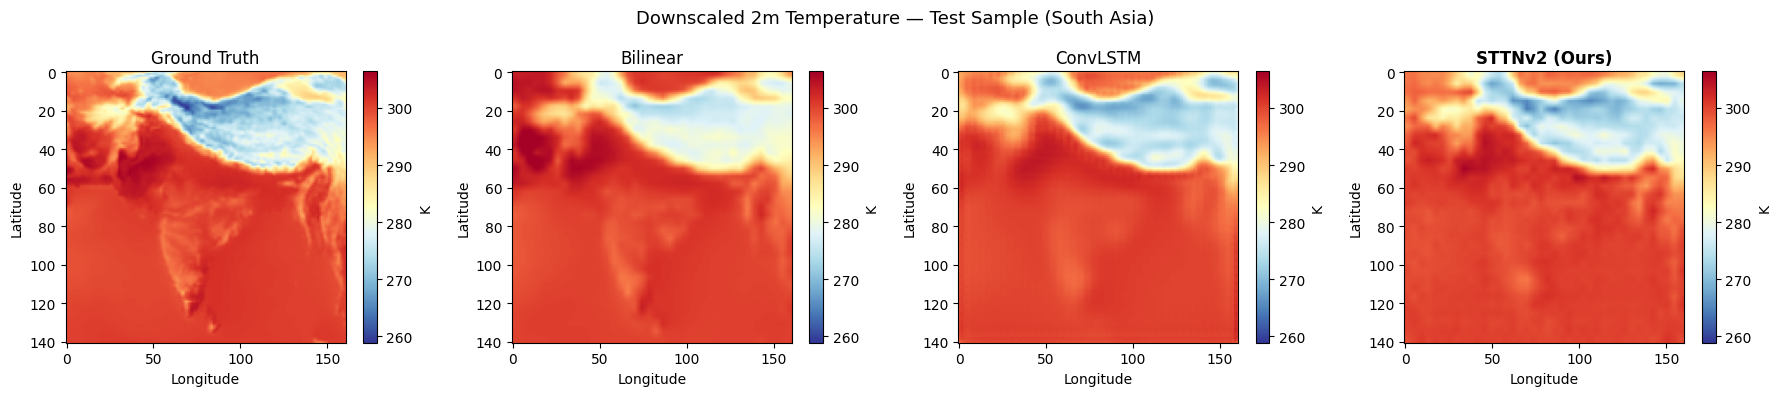


Figures saved.


In [16]:
print("=== Final Test Set Evaluation (100 epochs, fair comparison) ===\n")

bilinear_eval = BilinearBaseline(target_size=(141, 161)).to(device)
preds_b, rmse_b, mae_b, r_b = evaluate(bilinear_eval, "Bilinear",
                                        X_test, Y_test, target_mean, target_std)
preds_c, rmse_c, mae_c, r_c = evaluate(convlstm2,    "ConvLSTM",
                                        X_test, Y_test, target_mean, target_std)
preds_s, rmse_s, mae_s, r_s = evaluate(sttn_v2,      "STTNv2",
                                        X_test, Y_test, target_mean, target_std)

truth_k = Y_test * target_std + target_mean

print(f"\n=== Improvement Summary ===")
print(f"STTN vs Bilinear — RMSE reduction : {((rmse_b-rmse_s)/rmse_b)*100:.1f}%")
print(f"STTN vs ConvLSTM — RMSE difference: {rmse_s - rmse_c:+.4f} K "
      f"({'better' if rmse_s < rmse_c else 'worse'})")

# --- Attention map analysis ---
sttn_v2.eval()
sample_idx = 20
sample_x   = torch.tensor(X_test[sample_idx:sample_idx+1],
                           dtype=torch.float32).to(device)
with torch.no_grad():
    _, attn_weights = sttn_v2(sample_x, return_attn=True)

attn_map  = attn_weights[0].cpu().numpy()   # (T*S, T*S)
attn_mean = attn_map.mean(axis=0)           # avg attention received per token

H_p, W_p      = 35 // 4, 40 // 4           # 8, 10
attn_spatial  = attn_mean.reshape(12, H_p, W_p)
attn_temporal = attn_spatial.mean(axis=0)  # (8, 10) — spatial importance
attn_per_time = attn_spatial.sum(axis=(1,2))  # (12,) — temporal importance

# Check if attention is now differentiated
print(f"\n=== Attention Diagnostics ===")
print(f"Spatial attn  — min: {attn_temporal.min():.6f}, "
      f"max: {attn_temporal.max():.6f}, "
      f"std: {attn_temporal.std():.6f}")
print(f"Temporal attn — min: {attn_per_time.min():.4f}, "
      f"max: {attn_per_time.max():.4f}, "
      f"std: {attn_per_time.std():.6f}")
print(f"Temporal attn values: {attn_per_time.round(4)}")

# --- Figures ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

im1 = axes[0].imshow(attn_temporal, cmap='hot', aspect='auto')
axes[0].set_title("Mean Attention Weight per Spatial Patch\n(averaged over timesteps)",
                  fontweight='bold')
axes[0].set_xlabel("Longitude patches")
axes[0].set_ylabel("Latitude patches")
plt.colorbar(im1, ax=axes[0], label='Attention weight')

colors = ['#d62728' if v == attn_per_time.max()
          else '#1f77b4' for v in attn_per_time]
axes[1].bar(range(1, 13), attn_per_time, color=colors, edgecolor='black')
axes[1].set_xlabel("Input Timestep (months prior to prediction)")
axes[1].set_ylabel("Total Attention")
axes[1].set_title("Attention Distribution Across Input Timesteps\n"
                  "(red = most attended month)", fontweight='bold')
axes[1].set_xticks(range(1, 13))

plt.suptitle("STTNv2 Self-Attention Analysis — South Asia 2m Temperature",
             fontsize=12)
plt.tight_layout()
plt.savefig("era5_data/attention_map_v2.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Prediction comparison ---
vmin = truth_k[sample_idx].min()
vmax = truth_k[sample_idx].max()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
titles = ['Ground Truth', 'Bilinear', 'ConvLSTM', 'STTNv2 (Ours)']
data   = [truth_k[sample_idx], preds_b[sample_idx],
          preds_c[sample_idx], preds_s[sample_idx]]

for ax, d, title in zip(axes, data, titles):
    im = ax.imshow(d, cmap='RdYlBu_r', vmin=vmin, vmax=vmax,
                   origin='upper', aspect='auto')
    ax.set_title(title,
                 fontweight='bold' if 'STTN' in title else 'normal')
    plt.colorbar(im, ax=ax, label='K')
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.suptitle("Downscaled 2m Temperature — Test Sample (South Asia)", fontsize=13)
plt.tight_layout()
plt.savefig("era5_data/prediction_comparison_v2.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nFigures saved.")